In [1]:
!pip install fastapi uvicorn pandas requests nest-asyncio pyngrok

In [2]:
import requests
import pandas as pd
import io
from statsmodels.tsa.seasonal import STL

In [3]:
url = "https://www.cpc.ncep.noaa.gov/data/indices/sstoi.indices"
response = requests.get(url)

print("Status:", response.status_code)
print(response.text[:1000])

Status: 200
YR MON  NINO1+2   ANOM   NINO3    ANOM   NINO4    ANOM NINO3.4    ANOM
1982   1   24.28   -0.24   25.84    0.17   28.01   -0.21   26.65    0.08
1982   2   25.38   -0.72   26.26   -0.11   27.99   -0.11   26.54   -0.20
1982   3   25.22   -1.38   26.92   -0.25   28.18   -0.05   27.09   -0.14
1982   4   24.57   -1.16   27.52   -0.05   28.61    0.10   27.83    0.02
1982   5   24.00   -0.62   27.70    0.49   29.19    0.40   28.37    0.49
1982   6   22.88   -0.29   27.10    0.46   29.46    0.62   28.35    0.65
1982   7   22.07    0.24   26.14    0.27   28.76   -0.02   27.57    0.27
1982   8   21.71    0.85   26.05    0.83   28.70    0.01   27.76    0.86
1982   9   21.91    1.33   26.50    1.49   28.91    0.24   28.01    1.24
1982  10   22.67    1.80   27.04    1.96   29.11    0.43   28.50    1.73
1982  11   24.40    2.78   27.39    2.19   28.85    0.18   28.50    1.68
1982  12   25.73    2.89   28.07    2.80   28.81    0.36   28.85    2.21
1983   1   26.82    2.30   28.37    2.69 

In [4]:
url = "https://www.cpc.ncep.noaa.gov/data/indices/sstoi.indices"
response = requests.get(url)

data = response.text

df_sst = pd.read_csv(io.StringIO(data), sep=r'\s+')

# Display the first few rows of the DataFrame
print(df_sst.head())

     YR  MON  NINO1+2  ANOM  NINO3  ANOM.1  NINO4  ANOM.2  NINO3.4  ANOM.3
0  1982    1    24.28 -0.24  25.84    0.17  28.01   -0.21    26.65    0.08
1  1982    2    25.38 -0.72  26.26   -0.11  27.99   -0.11    26.54   -0.20
2  1982    3    25.22 -1.38  26.92   -0.25  28.18   -0.05    27.09   -0.14
3  1982    4    24.57 -1.16  27.52   -0.05  28.61    0.10    27.83    0.02
4  1982    5    24.00 -0.62  27.70    0.49  29.19    0.40    28.37    0.49


In [5]:
df_sst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YR       535 non-null    int64  
 1   MON      535 non-null    int64  
 2   NINO1+2  535 non-null    float64
 3   ANOM     535 non-null    float64
 4   NINO3    535 non-null    float64
 5   ANOM.1   535 non-null    float64
 6   NINO4    535 non-null    float64
 7   ANOM.2   535 non-null    float64
 8   NINO3.4  535 non-null    float64
 9   ANOM.3   535 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 41.9 KB


In [6]:
df_sst.tail()

,YR,MON,NINO1+2,ANOM,NINO3,ANOM.1,NINO4,ANOM.2,NINO3.4,ANOM.3
530,2026,3,27.89,1.29,27.40,0.24,28.56,0.34,27.26,0.03
531,2026,4,27.25,1.52,28.12,0.55,29.33,0.82,28.28,0.47
532,2026,5,26.43,1.81,28.36,1.14,29.78,0.98,28.82,0.94
533,2026,6,26.01,2.83,28.40,1.75,30.07,1.23,29.26,1.55
534,2026,7,25.40,3.56,28.21,2.33,29.84,1.06,29.33,2.03


/tmp/ipykernel_681/1463036395.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(df_sst["YR"], p(df_sst["YR"]), "r--", label=f"Trend Line", color='green')


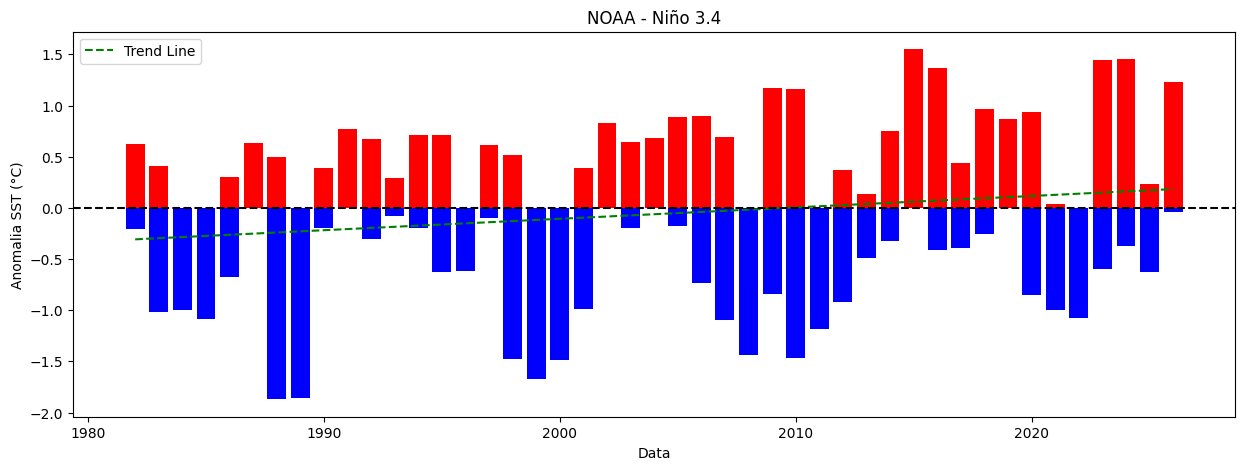

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 5))
plt.style.use('fast')
# Create a list of colors based on the 'ANOM.2' values
colors = ['red' if val > 0 else 'blue' if val < 0 else 'gray' for val in df_sst["ANOM.2"]]

plt.bar(
    df_sst["YR"],
    df_sst["ANOM.2"],
    color=colors # Apply the custom colors
)

# Calculate the linear trend line
z = np.polyfit(df_sst["YR"], df_sst["ANOM.2"], 1)
p = np.poly1d(z)
plt.plot(df_sst["YR"], p(df_sst["YR"]), "r--", label=f"Trend Line", color='green')

plt.axhline(0, linestyle="--", color='black')

plt.title("NOAA - Niño 3.4")
plt.xlabel("Data")
plt.ylabel("Anomalia SST (°C)")
plt.legend()
plt.show()

In [8]:
data_nino34 = pd.DataFrame({'YEAR': df_sst['YR'], 'ANOM.3': df_sst['ANOM.3']})
data_nino34

,YEAR,ANOM.3
0,1982,0.08
1,1982,-0.20
2,1982,-0.14
3,1982,0.02
4,1982,0.49
...,...,...
530,2026,0.03
531,2026,0.47
532,2026,0.94
533,2026,1.55


Média da Anomalia: -0.05
Desvio Padrão da Anomalia: 0.84
Anomalia Mínima: -2.22
Anomalia Máxima: 2.72
Mediana da Anomalia: -0.10


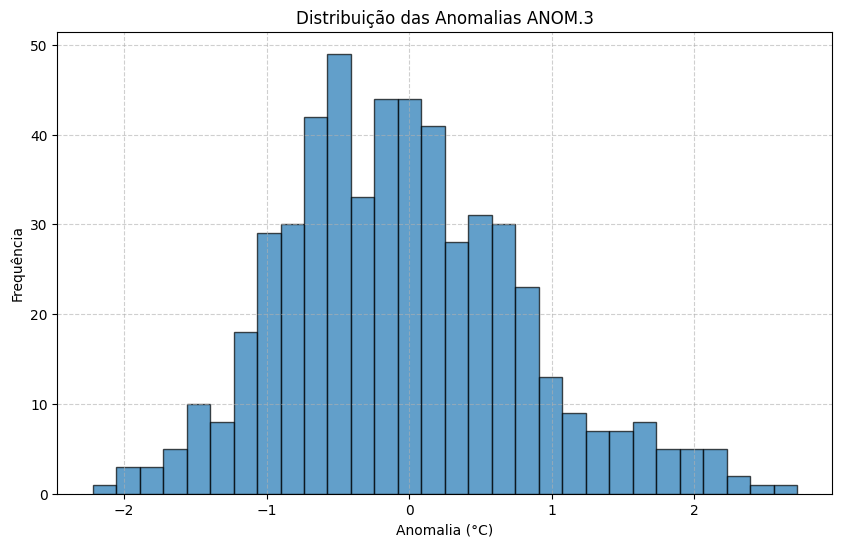

In [9]:
# Análise Estatística - Região El ninõ 3.4
mean_anomaly34 = data_nino34['ANOM.3'].mean()
std_anomaly34 = data_nino34['ANOM.3'].std()
min_anomaly34 = data_nino34['ANOM.3'].min()
max_anomaly34 = data_nino34['ANOM.3'].max()
median_anomaly34 = data_nino34['ANOM.3'].median()

print(f"Média da Anomalia: {mean_anomaly34:.2f}")
print(f"Desvio Padrão da Anomalia: {std_anomaly34:.2f}")
print(f"Anomalia Mínima: {min_anomaly34:.2f}")
print(f"Anomalia Máxima: {max_anomaly34:.2f}")
print(f"Mediana da Anomalia: {median_anomaly34:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data_nino34['ANOM.3'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribuição das Anomalias ANOM.3')
plt.xlabel('Anomalia (°C)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
correlation_matrix = df_sst.corr(numeric_only=True)
display(correlation_matrix['ANOM.3'].sort_values(ascending=False))

,ANOM.3
ANOM.3,1.000000
ANOM.1,0.941242
ANOM.2,0.884641
NINO3.4,0.878209
NINO4,0.826713
NINO3,0.658030
ANOM,0.646425
NINO1+2,0.293427
YR,0.073951
MON,-0.000137


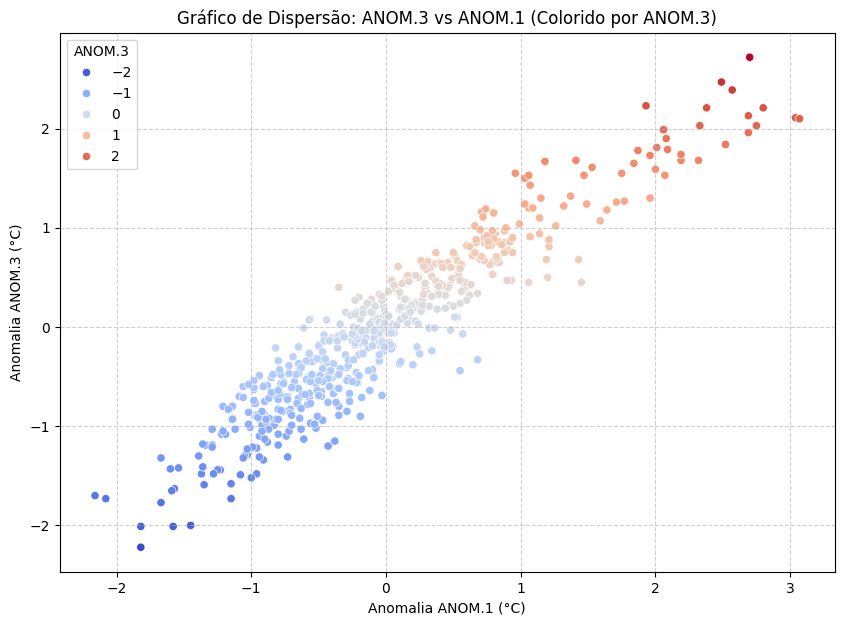

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='ANOM.1', y='ANOM.3', data=df_sst, hue='ANOM.3', palette='coolwarm')
plt.title('Gráfico de Dispersão: ANOM.3 vs ANOM.1 (Colorido por ANOM.3)')
plt.xlabel('Anomalia ANOM.1 (°C)')
plt.ylabel('Anomalia ANOM.3 (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

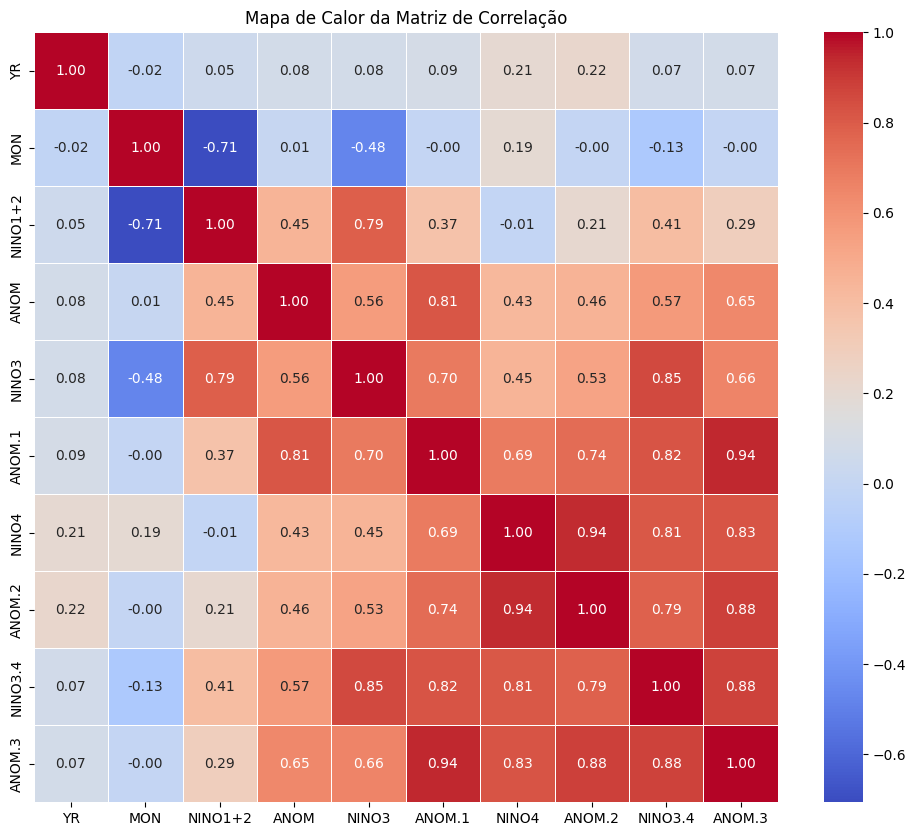

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()

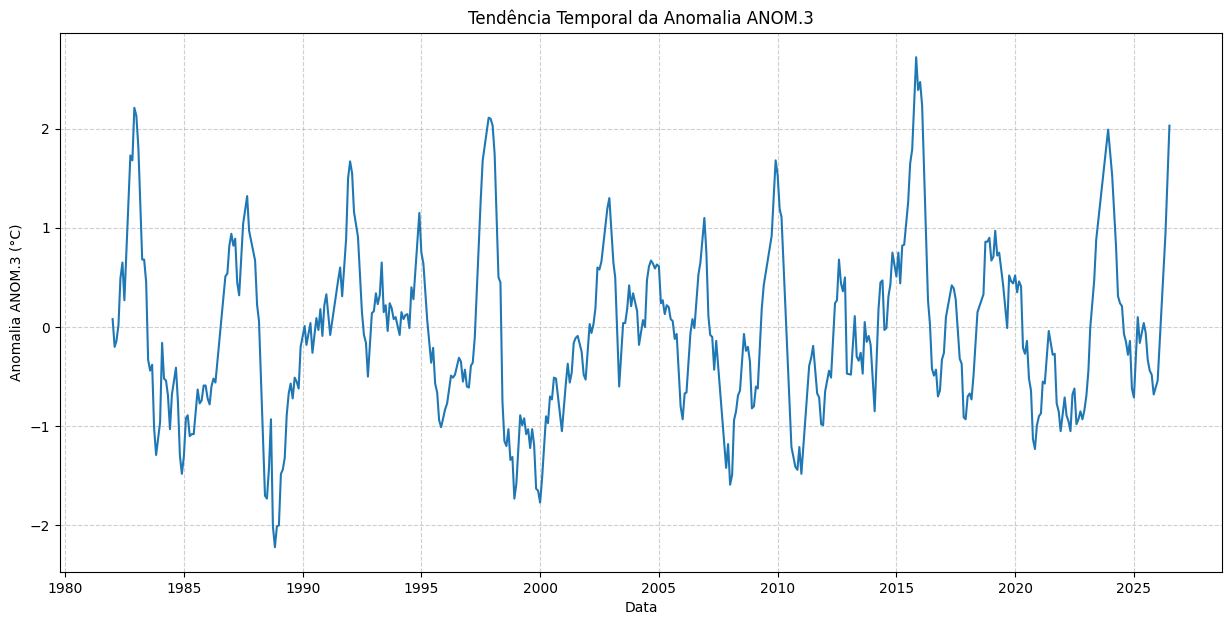

In [13]:
# Criar uma coluna de data a partir de 'YR' e 'MON'
df_sst['DATE'] = pd.to_datetime(df_sst['YR'].astype(str) + '-' + df_sst['MON'].astype(str))

# Definir 'DATE' como índice do DataFrame para facilitar a análise de séries temporais
df_sst_ts = df_sst.set_index('DATE')

# Plotar a tendência temporal de 'ANOM.3'
plt.figure(figsize=(15, 7))
sns.lineplot(x=df_sst_ts.index, y='ANOM.3', data=df_sst_ts)
plt.title('Tendência Temporal da Anomalia ANOM.3')
plt.xlabel('Data')
plt.ylabel('Anomalia ANOM.3 (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

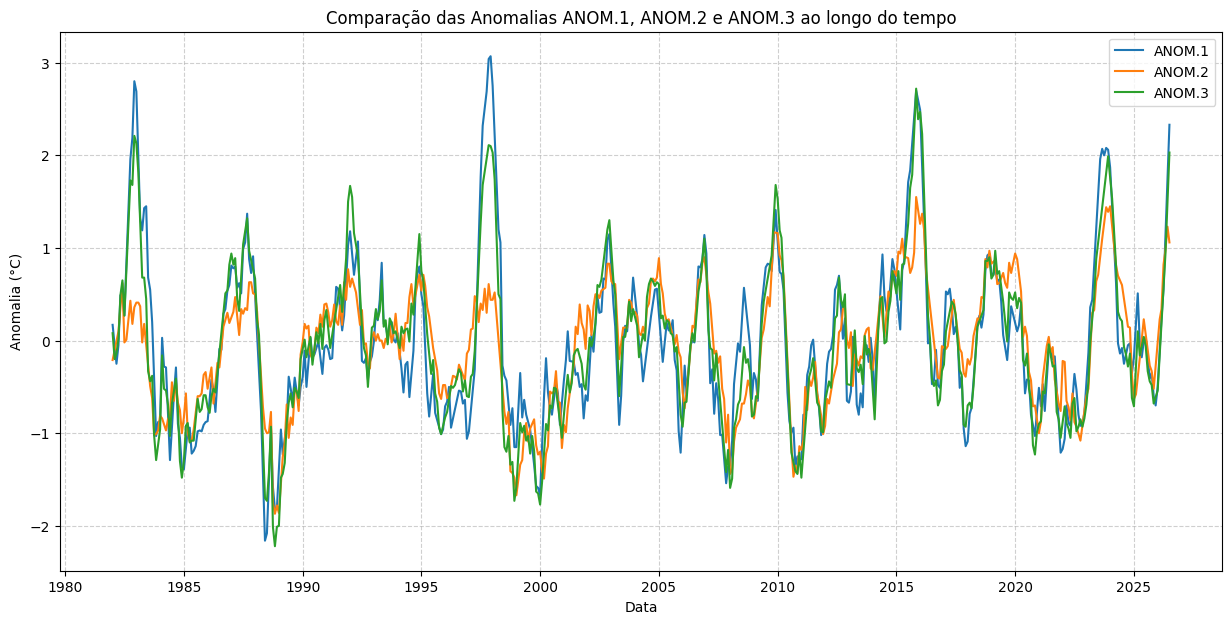

In [14]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df_sst_ts.index, y='ANOM.1', data=df_sst_ts, label='ANOM.1')
sns.lineplot(x=df_sst_ts.index, y='ANOM.2', data=df_sst_ts, label='ANOM.2')
sns.lineplot(x=df_sst_ts.index, y='ANOM.3', data=df_sst_ts, label='ANOM.3')
plt.title('Comparação das Anomalias ANOM.1, ANOM.2 e ANOM.3 ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Anomalia (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Identificação de Outliers na série temporal 'ANOM.3'

Q1 (25º percentil): -0.64
Q3 (75º percentil): 0.46
IQR (Intervalo Interquartil): 1.09
Limite Inferior para Outliers: -2.28
Limite Superior para Outliers: 2.10


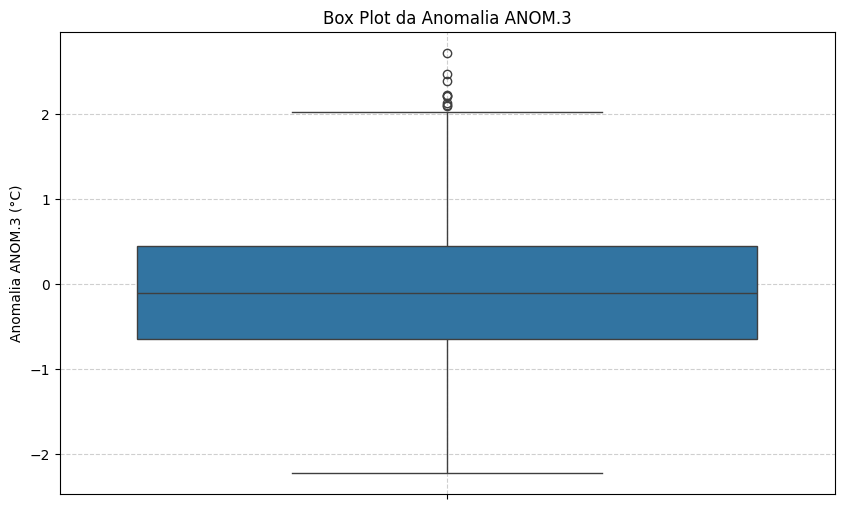

In [15]:
# Calcular os quartis (Q1 e Q3) e o Interquartile Range (IQR) para 'ANOM.3'
Q1 = df_sst_ts['ANOM.3'].quantile(0.25)
Q3 = df_sst_ts['ANOM.3'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25º percentil): {Q1:.2f}")
print(f"Q3 (75º percentil): {Q3:.2f}")
print(f"IQR (Intervalo Interquartil): {IQR:.2f}")
print(f"Limite Inferior para Outliers: {lower_bound:.2f}")
print(f"Limite Superior para Outliers: {upper_bound:.2f}")

# Plotar um box plot para visualizar os outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_sst_ts['ANOM.3'])
plt.title('Box Plot da Anomalia ANOM.3')
plt.ylabel('Anomalia ANOM.3 (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
# Identificar os outliers com base nos limites calculados
outliers = df_sst_ts[(df_sst_ts['ANOM.3'] < lower_bound) | (df_sst_ts['ANOM.3'] > upper_bound)]

print("Períodos com Anomalias ANOM.3 Extremas (Outliers):")
display(outliers[['ANOM.3']].sort_index())

Períodos com Anomalias ANOM.3 Extremas (Outliers):


,ANOM.3
DATE,
1982-12-01,2.21
1983-01-01,2.13
1997-11-01,2.11
1997-12-01,2.10
2015-10-01,2.21
2015-11-01,2.72
2015-12-01,2.39
2016-01-01,2.47
2016-02-01,2.23


### Distribuição de Frequências da Anomalia ANOM.3

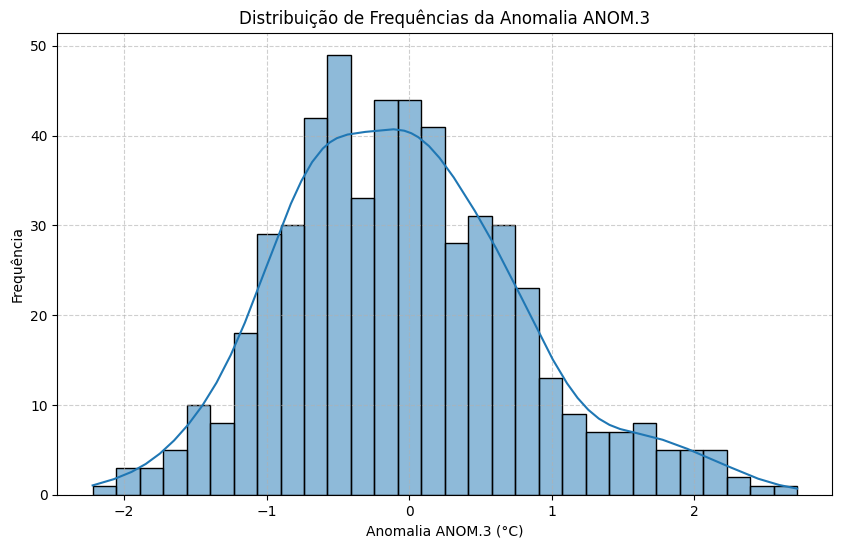

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df_sst_ts['ANOM.3'], bins=30, kde=True)
plt.title('Distribuição de Frequências da Anomalia ANOM.3')
plt.xlabel('Anomalia ANOM.3 (°C)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()